# Credit Risk Analysis and Default Prediction Using Home Credit Dataset

This notebook presents the initial results and code for the CIND820 capstone project.  
The objective is to explore the Home Credit Default Risk dataset, prepare the data, build multiple machine learning models, and compare their performance for default prediction.


In [2]:
# ============================================================
# STEP 1: Import required libraries
# ============================================================
# pandas and numpy are used for data handling and numerical operations.
# matplotlib and seaborn are used for visualizations.
# scikit-learn is used for preprocessing, modeling, evaluation, and cross-validation.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# This setting makes pandas display more columns when reviewing the dataset.
pd.set_option("display.max_columns", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# STEP: Mount Google Drive
# ============================================================
# This connects Colab to Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# STEP: Define dataset path
# ============================================================
# Update this path based on your folder name in Google Drive.

data_path = "/content/drive/MyDrive/HomeCredit/"

In [5]:
# ============================================================
# STEP: Load dataset from Google Drive
# ============================================================

df = pd.read_csv(data_path + "application_train.csv")

# Quick check
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single /

In [6]:
desc = pd.read_csv(
    data_path + "HomeCredit_columns_description.csv",
    encoding='latin1'
)

desc.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [7]:
# ============================================================
# STEP 2: Create a working copy of the dataset
# ============================================================
# We NEVER modify the original dataset directly.
# This helps avoid mistakes and keeps the raw data intact.

df_model = df.copy()

print("Working dataset created.")

Working dataset created.


In [8]:
# ============================================================
# STEP 3: Dataset overview
# ============================================================
# This step checks the size of the dataset and the number of variable types.
# It helps us understand the scale and structure before preprocessing.

print("Dataset shape:", df.shape)

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Number of numerical columns:", len(numeric_columns))
print("Number of categorical columns:", len(categorical_columns))

Dataset shape: (307511, 122)
Number of numerical columns: 106
Number of categorical columns: 16


In [9]:
# Display basic dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [10]:
# ============================================================
# STEP 4: Analyze target distribution
# ============================================================
# This checks whether the dataset is balanced or imbalanced.
# In credit risk data, default cases are usually much fewer than non-default cases.

target_counts = df["TARGET"].value_counts()
target_percentage = df["TARGET"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percentage)

Target counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentages:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


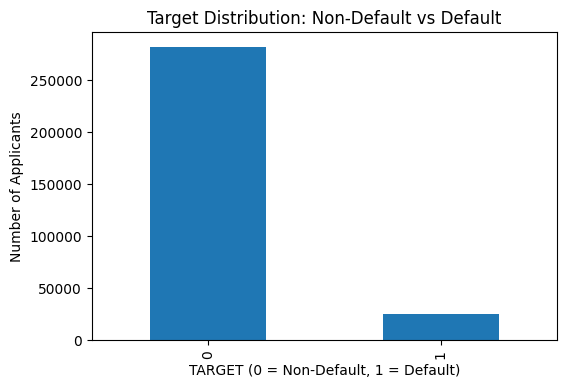

In [11]:
# Visualize the target distribution
plt.figure(figsize=(6, 4))
df["TARGET"].value_counts().plot(kind="bar")
plt.title("Target Distribution: Non-Default vs Default")
plt.xlabel("TARGET (0 = Non-Default, 1 = Default)")
plt.ylabel("Number of Applicants")
plt.show()

In [12]:
# ============================================================
# STEP 5: Missing value analysis
# ============================================================
# This step identifies variables with the highest number of missing values.
# Missing values are important because they affect model quality and preprocessing decisions.

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": missing_percent
})

missing_summary.head(20)

,Missing Count,Missing Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [13]:
# ============================================================
# STEP 6: Summary statistics
# ============================================================
# Summary statistics help identify the scale, spread, and possible outliers
# in numerical variables such as income, credit amount, and annuity.

df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,...,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,...,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,...,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.977752,0.755746,0.044595,0.078078,0.149213,0.225897,0.231625,0.067169,0.101954,0.108607,0.008651,0.028236,0.102547,1.422245,0.143421,1.405292,0.100049,-962.858788,0.000042,0.710023,0.000081,0.015115,0.088055,0.000192

In [14]:
# ============================================================
# STEP 7: Feature engineering
# ============================================================
# These new features are created using business logic.
# Ratios are useful in credit risk because raw amounts alone may not show affordability.
# For example, a large loan may be risky for a low-income applicant but acceptable for a high-income applicant.

df_model = df.copy()

# Credit-to-income ratio: shows how large the loan is compared to applicant income.
df_model["CREDIT_INCOME_RATIO"] = df_model["AMT_CREDIT"] / df_model["AMT_INCOME_TOTAL"]

# Annuity-to-income ratio: shows repayment burden compared to applicant income.
df_model["ANNUITY_INCOME_RATIO"] = df_model["AMT_ANNUITY"] / df_model["AMT_INCOME_TOTAL"]

# Credit-to-annuity ratio: approximates the relationship between loan size and scheduled payment.
df_model["CREDIT_ANNUITY_RATIO"] = df_model["AMT_CREDIT"] / df_model["AMT_ANNUITY"]

# Replace infinite values caused by division by zero with missing values.
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

print("New features created successfully.")

New features created successfully.


In [15]:
# ============================================================
# STEP 8: Select features for initial modeling
# ============================================================
# For Milestone 3, we use a manageable set of important variables.
# This keeps the model reproducible, readable, and suitable for a clear code walkthrough.
# More advanced work can later include additional linked tables.

selected_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "CNT_CHILDREN",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "REGION_RATING_CLIENT",
    "REGION_RATING_CLIENT_W_CITY",
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO"
]

X = df_model[selected_features]
y = df_model["TARGET"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (307511, 18)
Target shape: (307511,)


In [16]:
# ============================================================
# STEP 9: Separate numerical and categorical features
# ============================================================
# Numerical and categorical variables require different preprocessing.
# Numerical variables will be imputed and scaled.
# Categorical variables will be imputed and one-hot encoded.

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO']

Categorical features:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']


In [17]:
# ============================================================
# STEP 10: Build preprocessing pipeline
# ============================================================
# Pipeline design improves reproducibility and code readability.
# The same preprocessing steps will be applied consistently to all models.

numeric_transformer = Pipeline(steps=[
    # Median is used because financial variables may contain extreme values.
    ("imputer", SimpleImputer(strategy="median")),

    # Scaling is important for Logistic Regression.
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    # Missing categorical values are replaced with the most frequent category.
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # One-hot encoding converts categories into model-readable numeric columns.
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [18]:
# ============================================================
# STEP 11: Train-test split
# ============================================================
# The dataset is split into training and testing sets.
# stratify=y keeps the same default/non-default ratio in both sets.
# This is important because the target variable is imbalanced.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("Testing target distribution:")
print(y_test.value_counts(normalize=True))

Training feature shape: (246008, 18)
Testing feature shape: (61503, 18)
Training target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
Testing target distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [19]:
# ============================================================
# STEP 12: Define machine learning models
# ============================================================

from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=10,  # IMPORTANT for imbalance
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

print("Upgraded models defined.")



Upgraded models defined.


In [20]:
# ============================================================
# STEP 13: Train and evaluate each model
# ============================================================

results = []
trained_pipelines = {}

threshold = 0.5  # Standard threshold for initial model comparison

for model_name, model in models.items():

    print("=" * 60)
    print(f"Training model: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = pipeline

    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("ROC-AUC:", roc_auc)

Training model: Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.61      0.74     56538
           1       0.12      0.61      0.20      4965

    accuracy                           0.61     61503
   macro avg       0.53      0.61      0.47     61503
weighted avg       0.88      0.61      0.70     61503

ROC-AUC: 0.6449022459633509
Training model: Random Forest
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.74      0.83     56538
           1       0.15      0.51      0.23      4965

    accuracy                           0.72     61503
   macro avg       0.55      0.62      0.53     61503
weighted avg       0.88      0.72      0.78     61503

ROC-AUC: 0.6797967213061026
Training model: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:05:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     56538
           1       0.15      0.56      0.24      4965

    accuracy                           0.72     61503
   macro avg       0.55      0.65      0.53     61503
weighted avg       0.89      0.72      0.78     61503

ROC-AUC: 0.7015564236364374


In [21]:
# ============================================================
# STEP 14: Compare model performance
# ============================================================
# This table summarizes the performance of all models.
# It helps identify which algorithm performs best across different evaluation metrics.

results_df = pd.DataFrame(results)

# Sort models by ROC-AUC because ROC-AUC is commonly used for imbalanced classification problems.
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.717461,0.154570,0.559315,0.242205,0.701556
1,Random Forest,0.720469,0.146230,0.508963,0.227187,0.679797
0,Logistic Regression,0.608686,0.119755,0.605841,0.199980,0.644902


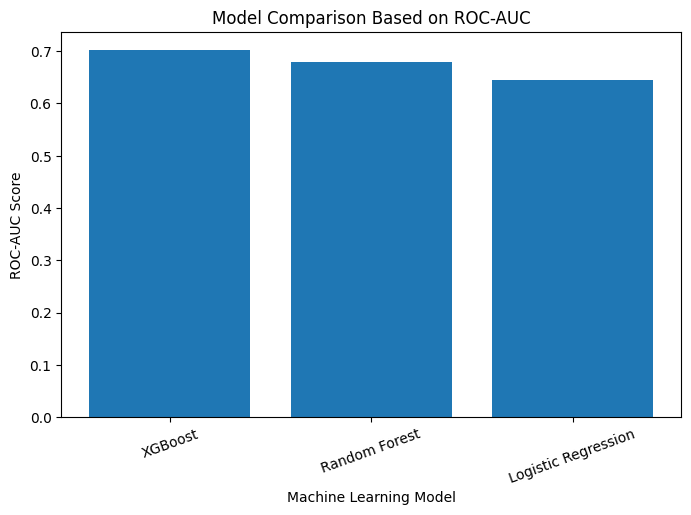

In [22]:
# ============================================================
# STEP 15: Visualize ROC-AUC comparison
# ============================================================
# This chart helps communicate model performance clearly in the report and video.

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["ROC-AUC"])
plt.title("Model Comparison Based on ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC Score")
plt.xticks(rotation=20)
plt.show()

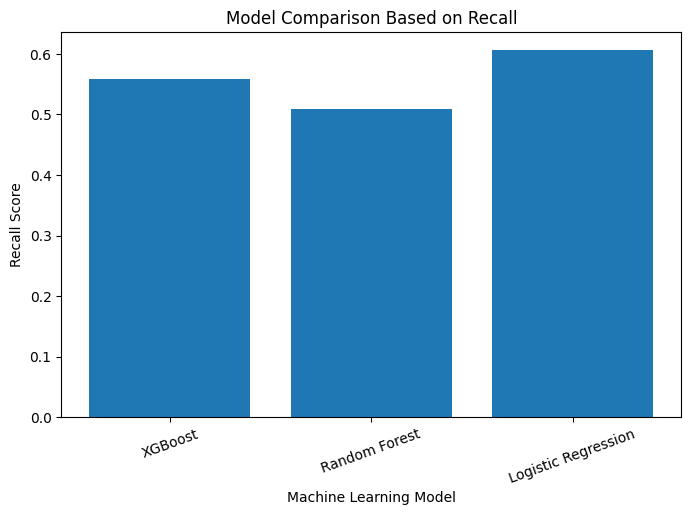

In [23]:
# ============================================================
# Visualize recall comparison
# ============================================================
# Recall is important because it measures how many actual default cases were detected.

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Recall"])
plt.title("Model Comparison Based on Recall")
plt.xlabel("Machine Learning Model")
plt.ylabel("Recall Score")
plt.xticks(rotation=20)
plt.show()

In [24]:
# ============================================================
# STEP 16: Cross-validation
# ============================================================
# Cross-validation is used as an experimental design to test model stability.
# Instead of relying on one train/test split only, 5-fold cross-validation evaluates
# the model across multiple data splits.
#
# ROC-AUC is used because it is suitable for binary classification with imbalanced data.

cv_results = []

for model_name, model in models.items():
    print("=" * 60)
    print(f"Cross-validating model: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV ROC-AUC": cv_scores.mean(),
        "Standard Deviation": cv_scores.std()
    })

    print("CV ROC-AUC scores:", cv_scores)
    print("Mean CV ROC-AUC:", cv_scores.mean())
    print("Standard deviation:", cv_scores.std())

cv_results_df = pd.DataFrame(cv_results).sort_values(by="Mean CV ROC-AUC", ascending=False)
cv_results_df

Cross-validating model: Logistic Regression
CV ROC-AUC scores: [0.65285166 0.64666725 0.64431041 0.6425955  0.64831753]
Mean CV ROC-AUC: 0.6469484716887635
Standard deviation: 0.0035414332201409836
Cross-validating model: Random Forest
CV ROC-AUC scores: [0.67967278 0.67617785 0.6715683  0.67204352 0.68190865]
Mean CV ROC-AUC: 0.6762742208884444
Standard deviation: 0.004082912144756729
Cross-validating model: XGBoost
CV ROC-AUC scores: [0.70502133 0.70111037 0.69670039 0.69560151 0.70493148]
Mean CV ROC-AUC: 0.7006730158096043
Standard deviation: 0.003968263005352888


,Model,Mean CV ROC-AUC,Standard Deviation
2,XGBoost,0.700673,0.003968
1,Random Forest,0.676274,0.004083
0,Logistic Regression,0.646948,0.003541


Best model based on ROC-AUC: XGBoost


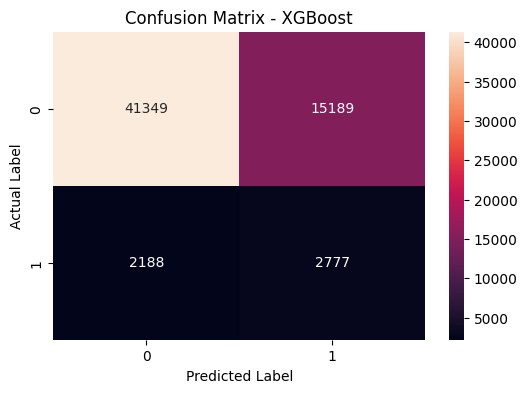

In [25]:
# ============================================================
# STEP 17: Confusion matrix for the best model
# ============================================================
# The best model is selected based on ROC-AUC.
# The confusion matrix shows correct and incorrect predictions:
# True Negative: correctly predicted non-default
# False Positive: predicted default but actually non-default
# False Negative: predicted non-default but actually default
# True Positive: correctly predicted default

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best model based on ROC-AUC:", best_model_name)

y_best_pred = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Initial Results and Interpretation

Three machine learning models were developed and compared: Logistic Regression, Random Forest, and XGBoost. Logistic Regression was used as an interpretable baseline model, while Random Forest and XGBoost were selected because they can capture nonlinear relationships between borrower characteristics and default risk.

The dataset is imbalanced, with significantly fewer default cases than non-default cases. For this reason, model evaluation was not based only on accuracy. Recall, F1-score, and ROC-AUC were also used to provide a more complete evaluation.

Cross-validation was included as part of the experimental design to evaluate the stability of model performance across multiple data splits. This improves the reliability of the initial findings and reduces dependence on a single train-test split.

The initial results show that model performance differs across algorithms. The best-performing model will be selected based on a combination of ROC-AUC, recall, and interpretability, rather than accuracy alone.

In [26]:
# ============================================================
# STEP 19: Save model comparison results
# ============================================================
# Saving results supports reproducibility and makes it easier to include results
# in the report, GitHub repository, and presentation.
from google.colab import files
results_df.to_csv("model_comparison_results.csv", index=False)
cv_results_df.to_csv("cross_validation_results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


In [27]:
# Download result files from Colab
files.download("model_comparison_results.csv")
files.download("cross_validation_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
# ============================================================
# STEP 21: Feature Importance (Random Forest)
# ============================================================

rf_model = trained_pipelines["Random Forest"].named_steps['model']

feature_names = trained_pipelines["Random Forest"].named_steps['preprocessor'].get_feature_names_out()

importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(10)

,0
numeric__DAYS_BIRTH,0.139127
numeric__CREDIT_ANNUITY_RATIO,0.131939
numeric__DAYS_EMPLOYED,0.118496
numeric__AMT_CREDIT,0.074410
numeric__AMT_ANNUITY,0.067615
numeric__CREDIT_INCOME_RATIO,0.061768
numeric__ANNUITY_INCOME_RATIO,0.061169
numeric__AMT_INCOME_TOTAL,0.045610
categorical__NAME_EDUCATION_TYPE_Higher education,0.038652
numeric__REGION_RATING_CLIENT_W_CITY,0.031140


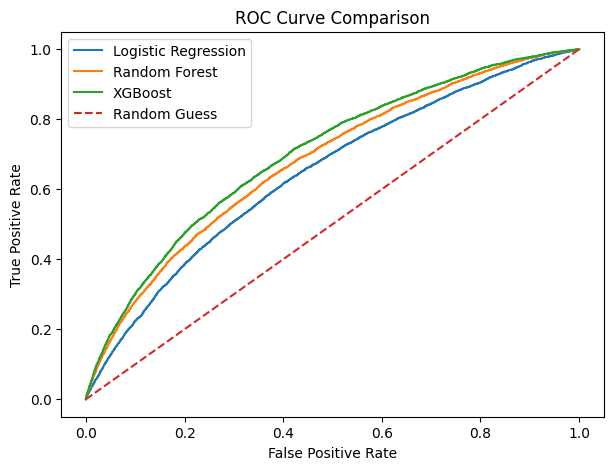

In [29]:
# ============================================================
# STEP 22: ROC Curve Comparison
# ============================================================
# This visual compares how well each model separates default and non-default cases.
# ROC-AUC is useful for imbalanced classification problems.

from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))

for model_name, pipeline in trained_pipelines.items():
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# STEP 23: Executive Summary

Three machine learning models were developed and compared: Logistic Regression, Random Forest, and XGBoost.

The dataset is highly imbalanced, with default cases representing approximately 8% of the total records. For this reason, model evaluation was based not only on accuracy, but also on recall, F1-score, and ROC-AUC.

XGBoost achieved the strongest overall performance based on ROC-AUC, while Logistic Regression achieved the highest recall. This indicates that XGBoost provided the best overall separation between default and non-default cases, while Logistic Regression detected a higher proportion of actual default cases.

Feature importance analysis showed that borrower age, employment duration, credit-to-annuity ratio, credit amount, annuity amount, credit-to-income ratio, annuity-to-income ratio, and income were among the most influential predictors.

Overall, the results demonstrate that machine learning can support credit risk assessment by identifying patterns associated with higher default risk.